# TCGA Quick Start

This notebook walks through loading a TCGA cohort with `syng_bts`, inspecting real expression data, loading the CVAE-synthesized counterpart, and a quick visual sanity check. The first call downloads the dataset (~34 MB for BRCA) and caches it under `~/.cache/syng-bts/tcga/`.

In [1]:
from syng_bts import list_tcga_datasets, load_tcga_dataset

list_tcga_datasets(short=True)

['BLCA',
 'BRCA',
 'COAD',
 'ESCA',
 'HNSC',
 'KICH',
 'KIRC',
 'KIRP',
 'LAML',
 'LIHC',
 'LUAD',
 'LUSC',
 'OV',
 'PAAD',
 'PCPG',
 'PRAD',
 'READ',
 'SARC',
 'SKCM',
 'STAD',
 'TGCT',
 'THCA',
 'THYM',
 'UCS']

## Loading a cohort

`load_tcga_dataset` returns a `TCGADataset` wrapping the cached HDF5 file.

In [2]:
ds = load_tcga_dataset("BRCA")
print(ds)

TCGADataset(name='BRCA_breast_carcinoma_estrogen_receptor_status', cancer_type='BRCA',
  raw: 1207 samples × 1881 features
  filtered: 1144 samples × 570 features
  groups: Negative/Positive
  processed: ['raw_norm', 'TC', 'DESeq']
  synthetic: ['raw_norm', 'TC', 'DESeq'] × ['CVAE1_5', 'CVAE1_10', 'CVAE1_20'] (1000 samples each)
  schema_version: 1.0, created: 2026-04-30T14:51:59.859278+00:00)


## Inspecting the real data

`ds.real(normalization)` returns a `(expression, groups)` tuple: the expression matrix as a DataFrame and the group labels as a Series. Per-slice metadata (HDF5 attrs) is held on the underlying `Subset` and reachable via `ds.processed[normalization]`.

In [3]:
real_df, real_groups = ds.real("TC")
print("Shape:", real_df.shape)
print("Groups:")
print(real_groups.value_counts())
print("Metadata:", ds.processed["TC"].metadata)

Shape: (1144, 570)
Groups:
groups
Positive    887
Negative    257
Name: count, dtype: int64
Metadata: {'normalization_method': 'TC_CPM', 'transform': 'log2(x+1)'}


## Loading synthetic samples

Each cohort ships with three CVAE-synthesized variants per normalization. Use `ds.synth(normalization, model)` to load them — same `(expression, groups)` tuple shape as `real()`.

In [4]:
synth_df, synth_groups = ds.synth("TC", "CVAE1_5")
print("Synthetic shape:", synth_df.shape)

Synthetic shape: (1000, 570)


## Quick visual check — UMAP

Compare real and synthetic on a 2D UMAP projection.

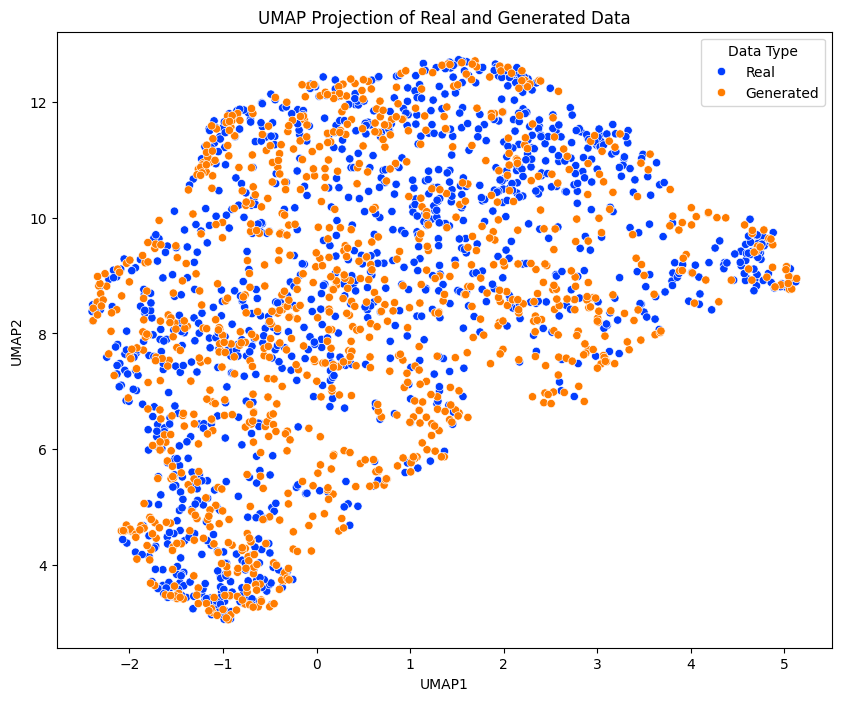

In [5]:
import warnings

from syng_bts import UMAP_eval

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _ = UMAP_eval(real_data=real_df, generated_data=synth_df)

## Cache management

Inspect the cache location and (optionally) clear the cache when you're done. `clear_tcga_cache()` removes the entire TCGA cache directory.

In [6]:
from pathlib import Path

from syng_bts import tcga_cache_dir, clear_tcga_cache

cache_root = tcga_cache_dir()
display = str(cache_root).replace(str(Path.home()), "~")
print("Cache root:", display)
# clear_tcga_cache()  # Uncomment to wipe the cache

Cache root: ~/.cache/syng-bts/tcga
